In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df_sissi = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
df_sissiz_mono = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx"))
df_sissiz_di = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx"))
df_multiperm_mono = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx"))
df_multiperm_di = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx"))
df_aln_shuffle = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx"))

In [5]:
df_sissi.head(10)

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.,File
0,0.8856,0.8770,0.0042,0.6048,0.4930,-91.01,-8.12,4.73,-17.54,pos_sample_output_55.txt
1,0.8703,0.8596,0.0042,0.6407,0.4768,-85.20,-3.54,2.45,-33.39,pos_sample_output_89.txt
2,0.8815,0.8738,0.0037,0.6319,0.5034,-102.79,-5.98,3.44,-28.15,pos_sample_output_72.txt
3,0.8853,0.8774,0.0039,0.5775,0.4584,-76.68,-6.24,3.30,-21.36,pos_sample_output_20.txt
4,0.8863,0.8779,0.0041,0.6734,0.5127,-105.91,-9.52,4.44,-21.70,pos_sample_output_97.txt
5,0.8780,0.8687,0.0046,0.6482,0.4950,-95.02,-7.14,4.00,-21.97,pos_sample_output_37.txt
6,0.8754,0.8653,0.0052,0.5838,0.4691,-84.46,-4.49,3.16,-25.27,pos_sample_output_87.txt
7,0.8590,0.8483,0.0047,0.5576,0.4777,-81.20,-3.33,3.10,-25.11,pos_sample_output_12.txt
8,0.8778,0.8701,0.0046,0.6170,0.4477,-81.04,-4.43,3.18,-24.12,pos_sample_output_68.txt
9,0.8820,0.8742,0.0047,0.7268,0.4778,-106.38,-6.48,3.66,-27.28,pos_sample_output_11.txt


In [6]:
df_sissi[['Mean Pairwise Identity (MPI) of the input alignment',
        'Average MPI of the sampled alignments.',
        'Standard deviation of the MPIs of the sampled alignments',
        'Structural Conservation Index (SCI)',	
        'GC-Content',
        'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
        'Average consensus MFE in the sampled alignments',
        'Standard deviation of the consensus MFE in the sampled alignments',
        'z-score calculated from 7. 8. and 9.']].describe()

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,0.874451,0.864875,0.004591,0.585270,0.488291,-85.926300,-5.88540,3.446100,-23.610500
std,0.007569,0.007920,0.000391,0.070697,0.026756,12.788426,1.62772,0.501599,4.473365
min,0.849600,0.840100,0.003700,0.414100,0.421800,-128.040000,-13.21000,2.280000,-35.900000
25%,0.869800,0.859975,0.004300,0.535175,0.469850,-93.505000,-6.89500,3.122500,-26.117500
50%,0.875050,0.865300,0.004600,0.584350,0.488000,-85.280000,-5.82500,3.385000,-23.315000
75%,0.879775,0.870700,0.004900,0.631675,0.507400,-76.972500,-4.61250,3.820000,-20.842500
max,0.889000,0.880800,0.005500,0.792000,0.546100,-56.460000,-2.90000,5.190000,-13.940000


In [7]:
df_sissiz_mono.head(10)

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.,File
0,0.8736,0.8628,0.0034,0.0577,0.5127,-7.27,-9.87,4.02,0.65,neg_sample_SISSIz_mono_output_60_175.txt
1,0.8792,0.8697,0.0038,0.0079,0.4329,-0.77,-5.06,3.49,1.23,neg_sample_SISSIz_mono_output_20_322.txt
2,0.8691,0.8580,0.0042,0.0558,0.4767,-5.83,-5.85,3.75,0.00,neg_sample_SISSIz_mono_output_88_522.txt
3,0.8413,0.8301,0.0047,0.0415,0.5297,-5.45,-5.54,3.38,0.03,neg_sample_SISSIz_mono_output_23_838.txt
4,0.8683,0.8576,0.0036,0.0015,0.4590,-0.17,-6.27,3.62,1.69,neg_sample_SISSIz_mono_output_62_322.txt
5,0.8649,0.8532,0.0043,0.0870,0.5411,-11.36,-9.52,4.38,-0.42,neg_sample_SISSIz_mono_output_65_491.txt
6,0.8629,0.8528,0.0037,0.0120,0.4624,-1.29,-6.49,3.36,1.55,neg_sample_SISSIz_mono_output_38_840.txt
7,0.8746,0.8646,0.0042,0.0865,0.4813,-9.51,-8.94,3.34,-0.17,neg_sample_SISSIz_mono_output_33_485.txt
8,0.8696,0.8581,0.0043,0.0276,0.4921,-3.34,-8.23,3.97,1.23,neg_sample_SISSIz_mono_output_16_182.txt
9,0.8533,0.8416,0.0051,0.0412,0.4714,-3.83,-3.92,2.86,0.03,neg_sample_SISSIz_mono_output_47_686.txt


In [8]:
df_sissiz_mono[['Mean Pairwise Identity (MPI) of the input alignment',
        'Average MPI of the sampled alignments.',
        'Standard deviation of the MPIs of the sampled alignments',
        'Structural Conservation Index (SCI)',	
        'GC-Content',
        'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
        'Average consensus MFE in the sampled alignments',
        'Standard deviation of the consensus MFE in the sampled alignments',
        'z-score calculated from 7. 8. and 9.']].describe()


# Example neg_sample_SISSIz_mono_output_60_175.txt
# z-score = (RNAalifold consensus Minimum Free Energy (MFE) of the original alignment - Average consensus MFE in the sampled alignments) / Standard deviation of the consensus MFE in the sampled alignments
# z-score = (-7.27 - -9.87) / 4.02 = 0,65

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.865836,0.855446,0.004228,0.039971,0.488262,-4.689540,-7.278781,3.637573,0.719268
std,0.009047,0.009256,0.000388,0.027651,0.035076,3.409589,2.123409,0.539155,0.759088
min,0.827600,0.816400,0.002700,-0.000000,0.350300,-22.830000,-17.800000,1.740000,-3.890000
25%,0.859900,0.849300,0.004000,0.018600,0.464700,-6.700000,-8.660000,3.270000,0.260000
50%,0.866300,0.855900,0.004200,0.036400,0.488900,-4.150000,-7.140000,3.630000,0.830000
75%,0.872200,0.862000,0.004500,0.056900,0.512100,-2.070000,-5.730000,4.000000,1.280000
max,0.892600,0.884400,0.006000,0.176400,0.611800,0.000000,-1.690000,5.970000,2.860000


In [9]:
df_sissiz_di.head(10)

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.,File
0,0.8685,0.8569,0.0044,0.0786,0.4970,-9.66,-10.22,4.67,0.12,neg_sample_SISSIz_di_output_7_471.txt
1,0.8805,0.8699,0.0039,0.0434,0.5350,-5.74,-12.09,4.88,1.30,neg_sample_SISSIz_di_output_69_45.txt
2,0.8493,0.8382,0.0041,0.0365,0.4919,-4.39,-5.12,3.16,0.23,neg_sample_SISSIz_di_output_76_235.txt
3,0.8667,0.8554,0.0043,0.0096,0.4767,-1.01,-7.90,4.32,1.60,neg_sample_SISSIz_di_output_48_902.txt
4,0.8711,0.8612,0.0042,0.0597,0.5329,-7.73,-11.36,4.29,0.85,neg_sample_SISSIz_di_output_9_815.txt
5,0.8611,0.8526,0.0036,0.0770,0.4825,-8.63,-6.44,3.28,-0.67,neg_sample_SISSIz_di_output_29_568.txt
6,0.8703,0.8612,0.0036,0.1082,0.5236,-14.59,-9.56,4.35,-1.16,neg_sample_SISSIz_di_output_91_913.txt
7,0.8512,0.8410,0.0050,0.0230,0.4382,-2.42,-4.36,2.43,0.80,neg_sample_SISSIz_di_output_1_229.txt
8,0.8572,0.8463,0.0043,0.0894,0.4659,-9.99,-5.28,3.26,-1.44,neg_sample_SISSIz_di_output_92_765.txt
9,0.8576,0.8477,0.0043,0.0139,0.4876,-1.63,-5.41,3.28,1.15,neg_sample_SISSIz_di_output_73_895.txt


In [10]:
df_sissiz_di[['Mean Pairwise Identity (MPI) of the input alignment',
        'Average MPI of the sampled alignments.',
        'Standard deviation of the MPIs of the sampled alignments',
        'Structural Conservation Index (SCI)',	
        'GC-Content',
        'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
        'Average consensus MFE in the sampled alignments',
        'Standard deviation of the consensus MFE in the sampled alignments',
        'z-score calculated from 7. 8. and 9.']].describe()

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.864899,0.854306,0.004242,0.049625,0.489272,-5.877318,-8.072087,3.873444,0.570776
std,0.009094,0.009258,0.000388,0.030788,0.035767,3.824714,2.387446,0.591971,0.808148
min,0.826700,0.814300,0.002700,-0.000000,0.354300,-26.960000,-22.030000,1.920000,-3.960000
25%,0.859000,0.848200,0.004000,0.026700,0.465100,-8.110000,-9.560000,3.460000,0.080000
50%,0.865300,0.854600,0.004200,0.046100,0.489600,-5.340000,-7.870000,3.850000,0.670000
75%,0.871400,0.860900,0.004500,0.068300,0.513600,-3.020000,-6.350000,4.260000,1.160000
max,0.893700,0.885500,0.006200,0.215300,0.617700,0.000000,-1.920000,7.050000,2.940000


In [11]:
df_multiperm_mono.head(10)

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.,File
0,0.8690,0.8602,0.0049,0.2117,0.4510,-22.67,-4.22,3.37,-5.48,neg_sample_MULTIPERM_mono_output_39_770.txt
1,0.8496,0.8409,0.0049,0.1893,0.5181,-24.54,-3.82,2.82,-7.34,neg_sample_MULTIPERM_mono_output_23_824.txt
2,0.8642,0.8575,0.0050,0.1777,0.5000,-21.70,-4.54,2.86,-5.99,neg_sample_MULTIPERM_mono_output_2_971.txt
3,0.8815,0.8729,0.0046,0.2782,0.5034,-34.47,-5.84,3.04,-9.41,neg_sample_MULTIPERM_mono_output_72_12.txt
4,0.8730,0.8631,0.0044,0.2223,0.4685,-24.16,-3.73,2.64,-7.75,neg_sample_MULTIPERM_mono_output_29_441.txt
5,0.8765,0.8665,0.0045,0.1637,0.4869,-18.11,-4.47,3.06,-4.46,neg_sample_MULTIPERM_mono_output_34_847.txt
6,0.8726,0.8625,0.0046,0.1959,0.5025,-24.84,-6.33,3.77,-4.92,neg_sample_MULTIPERM_mono_output_5_384.txt
7,0.8840,0.8760,0.0043,0.1405,0.4567,-15.80,-5.39,3.34,-3.11,neg_sample_MULTIPERM_mono_output_58_446.txt
8,0.8698,0.8593,0.0047,0.2395,0.5077,-29.05,-6.57,4.11,-5.47,neg_sample_MULTIPERM_mono_output_41_976.txt
9,0.8698,0.8591,0.0049,0.2215,0.5077,-28.08,-5.60,3.47,-6.47,neg_sample_MULTIPERM_mono_output_41_304.txt


In [12]:
df_multiperm_mono[['Mean Pairwise Identity (MPI) of the input alignment',
        'Average MPI of the sampled alignments.',
        'Standard deviation of the MPIs of the sampled alignments',
        'Structural Conservation Index (SCI)',	
        'GC-Content',
        'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
        'Average consensus MFE in the sampled alignments',
        'Standard deviation of the consensus MFE in the sampled alignments',
        'z-score calculated from 7. 8. and 9.']].describe()

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.874451,0.864934,0.004538,0.194130,0.488291,-22.883175,-5.462562,3.301855,-5.303137
std,0.007531,0.007888,0.000393,0.050483,0.026622,6.797357,1.477084,0.481819,1.802749
min,0.849600,0.837600,0.003000,0.023500,0.421800,-53.950000,-14.360000,1.580000,-16.640000
25%,0.869800,0.859600,0.004300,0.158500,0.469850,-27.510000,-6.380000,2.970000,-6.440000
50%,0.875050,0.865500,0.004500,0.192000,0.488000,-22.510000,-5.390000,3.290000,-5.170000
75%,0.879775,0.870400,0.004800,0.227800,0.507400,-17.890000,-4.370000,3.620000,-4.030000
max,0.889000,0.882600,0.006500,0.422500,0.546100,-2.640000,-1.640000,5.910000,0.520000


In [13]:
df_multiperm_di.head(10)

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.,File
0,0.8797,0.8705,0.0049,0.1569,0.4680,-16.60,-4.54,3.12,-3.87,neg_sample_MULTIPERM_di_output_70_754.txt
1,0.8723,0.8630,0.0046,0.2510,0.4925,-30.27,-5.88,3.46,-7.06,neg_sample_MULTIPERM_di_output_26_529.txt
2,0.8723,0.8604,0.0056,0.1924,0.4925,-23.27,-5.44,3.53,-5.05,neg_sample_MULTIPERM_di_output_26_917.txt
3,0.8759,0.8662,0.0045,0.1879,0.4941,-22.56,-6.34,3.45,-4.71,neg_sample_MULTIPERM_di_output_27_914.txt
4,0.8805,0.8694,0.0047,0.2850,0.4889,-33.13,-9.54,4.59,-5.14,neg_sample_MULTIPERM_di_output_59_636.txt
5,0.8656,0.8536,0.0049,0.2053,0.5192,-25.78,-4.97,3.03,-6.88,neg_sample_MULTIPERM_di_output_25_533.txt
6,0.8768,0.8665,0.0045,0.1581,0.4699,-18.23,-6.45,3.58,-3.29,neg_sample_MULTIPERM_di_output_18_951.txt
7,0.8630,0.8516,0.0049,0.1391,0.4328,-14.35,-4.16,2.78,-3.66,neg_sample_MULTIPERM_di_output_1_640.txt
8,0.8782,0.8681,0.0045,0.2211,0.5130,-27.94,-5.22,3.45,-6.58,neg_sample_MULTIPERM_di_output_53_982.txt
9,0.8761,0.8667,0.0044,0.3497,0.5044,-42.99,-5.62,3.81,-9.81,neg_sample_MULTIPERM_di_output_43_201.txt


In [14]:
df_multiperm_di[['Mean Pairwise Identity (MPI) of the input alignment',
        'Average MPI of the sampled alignments.',
        'Standard deviation of the MPIs of the sampled alignments',
        'Structural Conservation Index (SCI)',	
        'GC-Content',
        'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
        'Average consensus MFE in the sampled alignments',
        'Standard deviation of the consensus MFE in the sampled alignments',
        'z-score calculated from 7. 8. and 9.']].describe()

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.874451,0.864959,0.004536,0.193141,0.488291,-22.755578,-5.621597,3.341209,-5.153545
std,0.007531,0.007866,0.000391,0.051292,0.026622,6.877533,1.538601,0.497537,1.781275
min,0.849600,0.837800,0.003100,0.024900,0.421800,-54.910000,-14.640000,1.550000,-14.560000
25%,0.869800,0.859700,0.004300,0.156400,0.469850,-27.470000,-6.560000,3.000000,-6.280000
50%,0.875050,0.865500,0.004500,0.191000,0.488000,-22.400000,-5.530000,3.330000,-5.030000
75%,0.879775,0.870400,0.004800,0.227700,0.507400,-17.670000,-4.500000,3.660000,-3.890000
max,0.889000,0.883300,0.006400,0.425000,0.546100,-2.710000,-1.480000,5.710000,0.200000


In [15]:
df_aln_shuffle.head(10)

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.,File
0,0.8761,0.8679,0.0046,0.4862,0.5044,-62.40,-6.69,3.56,-15.64,neg_sample_ALIFOLDz_output_43_632.txt
1,0.8724,0.8624,0.0046,0.2680,0.4750,-31.79,-3.60,2.56,-11.03,neg_sample_ALIFOLDz_output_61_430.txt
2,0.8749,0.8655,0.0051,0.3376,0.4871,-44.11,-5.92,3.86,-9.90,neg_sample_ALIFOLDz_output_77_672.txt
3,0.8621,0.8526,0.0044,0.2573,0.4558,-30.75,-3.57,2.41,-11.28,neg_sample_ALIFOLDz_output_14_650.txt
4,0.8736,0.8628,0.0040,0.3739,0.4626,-40.54,-4.73,3.29,-10.88,neg_sample_ALIFOLDz_output_32_586.txt
5,0.8600,0.8501,0.0049,0.1840,0.4683,-19.20,-3.24,2.78,-5.73,neg_sample_ALIFOLDz_output_31_744.txt
6,0.8873,0.8770,0.0041,0.4605,0.4806,-54.32,-7.19,3.56,-13.23,neg_sample_ALIFOLDz_output_94_868.txt
7,0.8703,0.8601,0.0044,0.3363,0.4768,-38.33,-3.87,3.36,-10.24,neg_sample_ALIFOLDz_output_89_17.txt
8,0.8820,0.8743,0.0049,0.4254,0.4778,-49.74,-6.15,3.53,-12.34,neg_sample_ALIFOLDz_output_11_444.txt
9,0.8803,0.8699,0.0051,0.3027,0.4407,-32.42,-4.77,2.92,-9.47,neg_sample_ALIFOLDz_output_21_449.txt


In [16]:
df_aln_shuffle[['Mean Pairwise Identity (MPI) of the input alignment',
        'Average MPI of the sampled alignments.',
        'Standard deviation of the MPIs of the sampled alignments',
        'Structural Conservation Index (SCI)',	
        'GC-Content',
        'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
        'Average consensus MFE in the sampled alignments',
        'Standard deviation of the consensus MFE in the sampled alignments',
        'z-score calculated from 7. 8. and 9.']].describe()

,Mean Pairwise Identity (MPI) of the input alignment,Average MPI of the sampled alignments.,Standard deviation of the MPIs of the sampled alignments,Structural Conservation Index (SCI),GC-Content,RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.,Average consensus MFE in the sampled alignments,Standard deviation of the consensus MFE in the sampled alignments,z-score calculated from 7. 8. and 9.
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.874451,0.864974,0.004534,0.370919,0.488291,-46.384955,-5.618556,3.338883,-12.387286
std,0.007531,0.007891,0.000392,0.072506,0.026622,10.965085,1.434920,0.473168,3.457317
min,0.849600,0.837800,0.003100,0.103400,0.421800,-93.190000,-12.070000,1.680000,-36.990000
25%,0.869800,0.859700,0.004300,0.320800,0.469850,-53.770000,-6.570000,3.010000,-14.550000
50%,0.875050,0.865500,0.004500,0.371400,0.488000,-46.030000,-5.600000,3.340000,-12.140000
75%,0.879775,0.870400,0.004800,0.420600,0.507400,-38.520000,-4.530000,3.660000,-9.940000
max,0.889000,0.883000,0.006400,0.651500,0.546100,-11.750000,-2.010000,5.300000,-2.070000


## Mean Pairwise Identity (MPI) of the input alignment

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\1437701190.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


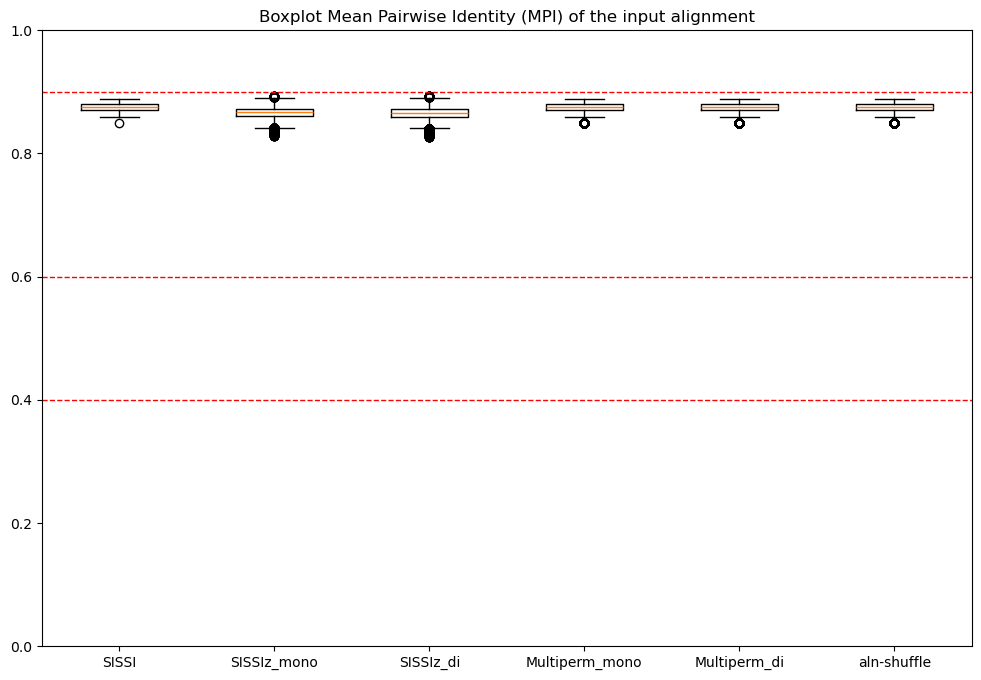

In [17]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['Mean Pairwise Identity (MPI) of the input alignment'] for df in dataframes]
thresholds = [0.40, 0.60, 0.90]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.ylim(0.0, 1.0)
plt.title('Boxplot Mean Pairwise Identity (MPI) of the input alignment')
plt.show()

## Average MPI of the sampled alignments.

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\1318570128.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


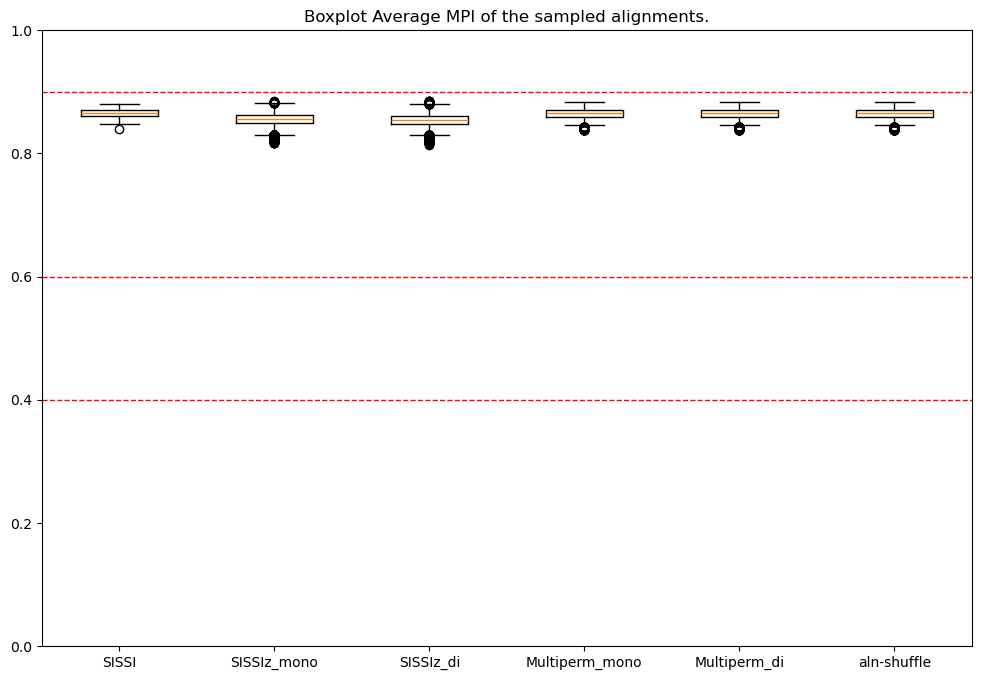

In [18]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['Average MPI of the sampled alignments.'] for df in dataframes]
thresholds = [0.40, 0.60, 0.90]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.ylim(0.0, 1.0)
plt.title('Boxplot Average MPI of the sampled alignments.')
plt.show()

## Standard deviation of the MPIs of the sampled alignments

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\4121038437.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


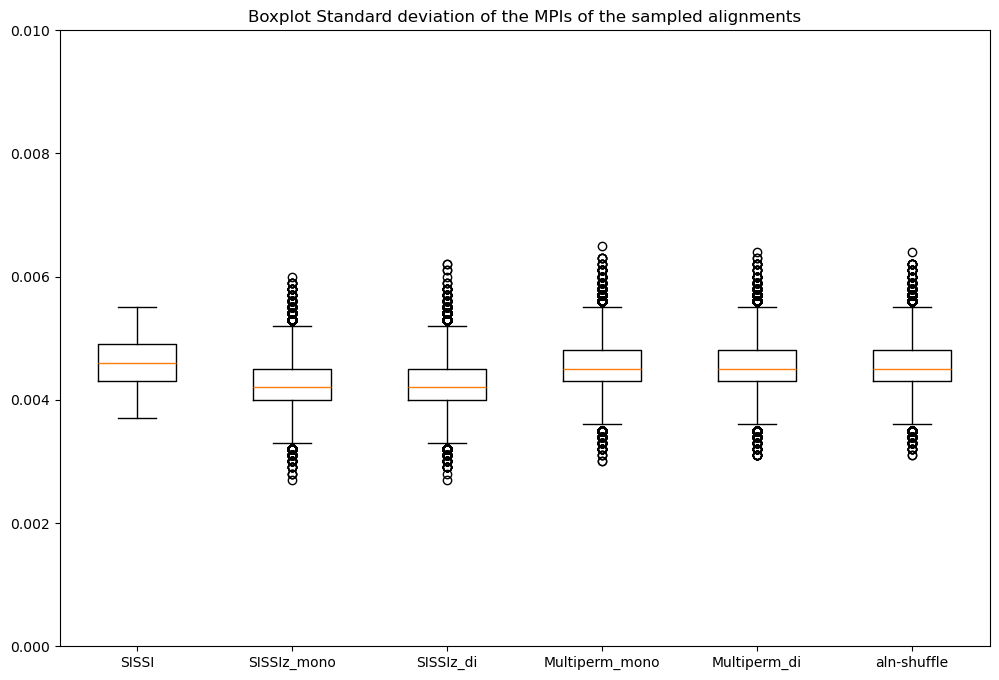

In [19]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['Standard deviation of the MPIs of the sampled alignments'] for df in dataframes]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.ylim(0.0, 0.01)
plt.title('Boxplot Standard deviation of the MPIs of the sampled alignments')
plt.show()

## Structural Conservation Index (SCI)

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\1306523587.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


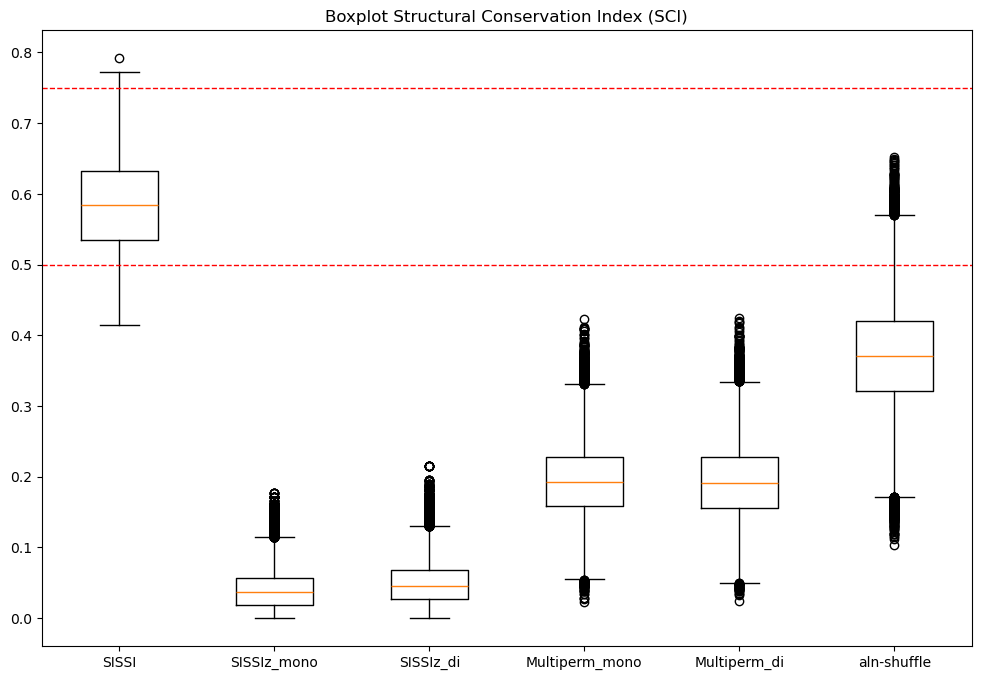

In [20]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['Structural Conservation Index (SCI)'] for df in dataframes]
thresholds = [0.5, 0.75]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot Structural Conservation Index (SCI)')
plt.show()

## GC-Content

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\3074007515.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


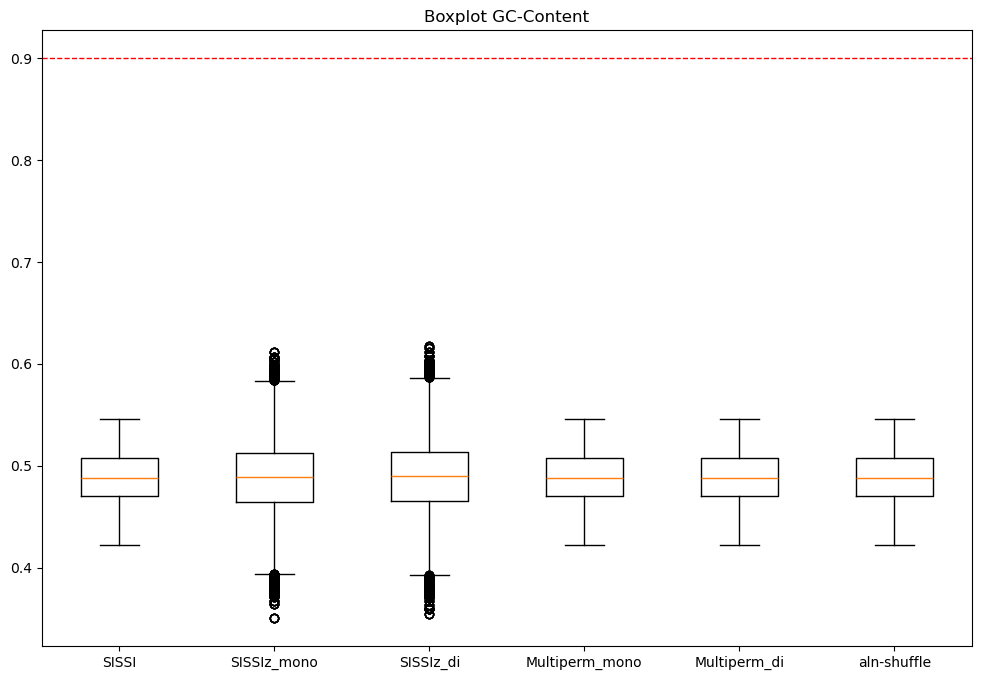

In [21]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['GC-Content'] for df in dataframes]
thresholds = [0.9]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot GC-Content')
plt.show()

## RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\45866791.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


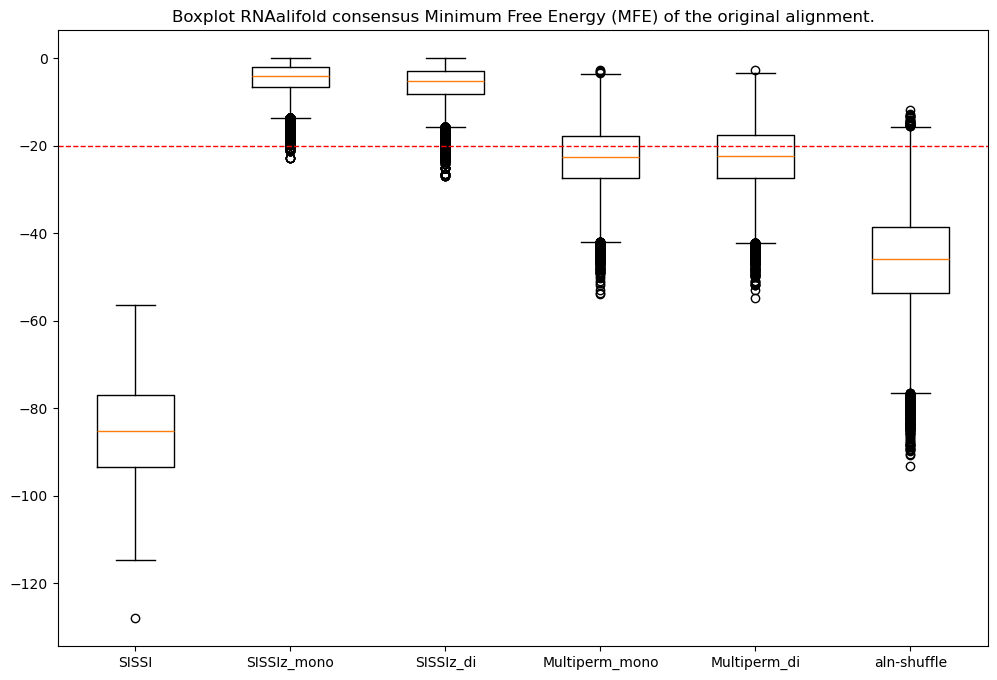

In [22]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.'] for df in dataframes]
thresholds = [-20]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.')
plt.show()

## Average consensus MFE in the sampled alignments

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\2536993985.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


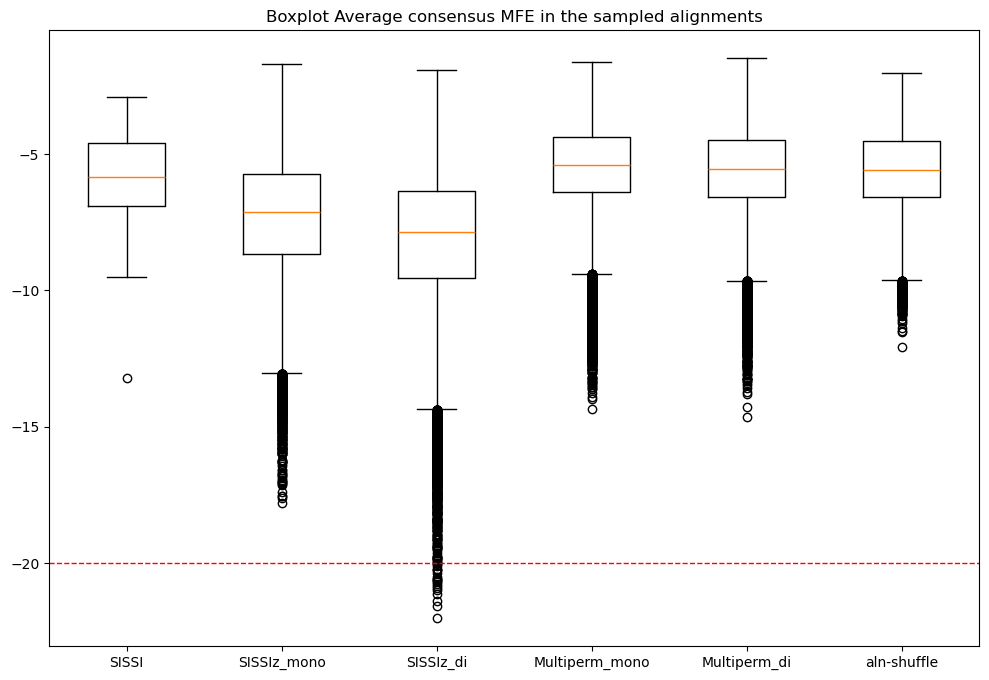

In [23]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['Average consensus MFE in the sampled alignments'] for df in dataframes]
thresholds = [-20]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot Average consensus MFE in the sampled alignments')
plt.show()

## Standard deviation of the consensus MFE in the sampled alignments

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\3641649075.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


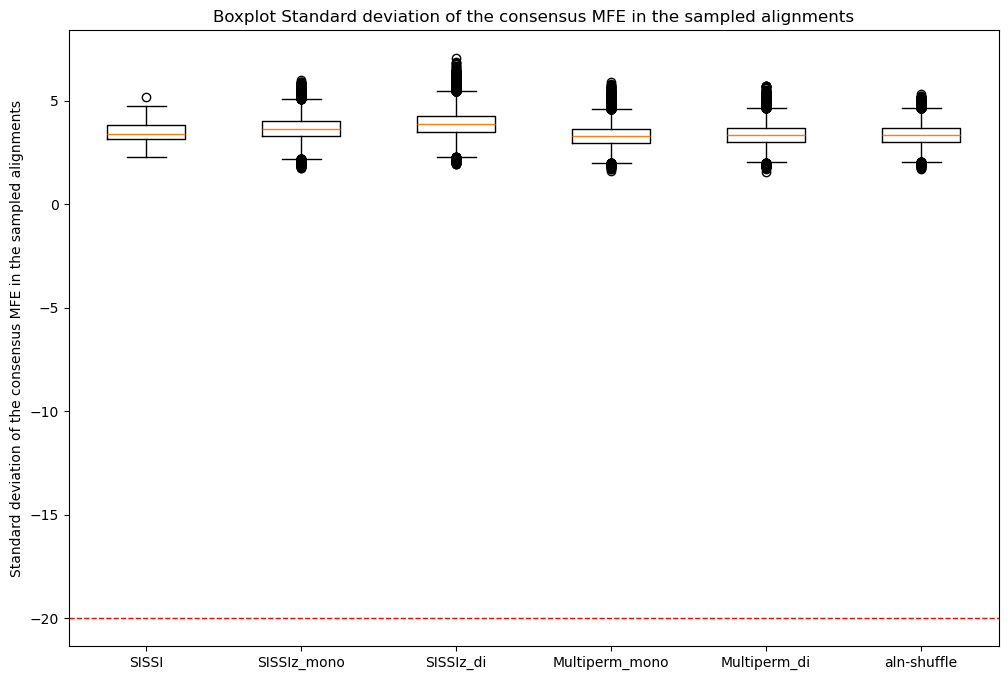

In [24]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['Standard deviation of the consensus MFE in the sampled alignments'] for df in dataframes]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot Standard deviation of the consensus MFE in the sampled alignments')
plt.ylabel('Standard deviation of the consensus MFE in the sampled alignments')
plt.show()

## z-score 

C:\Users\Stefan\AppData\Local\Temp\ipykernel_21712\1350217692.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


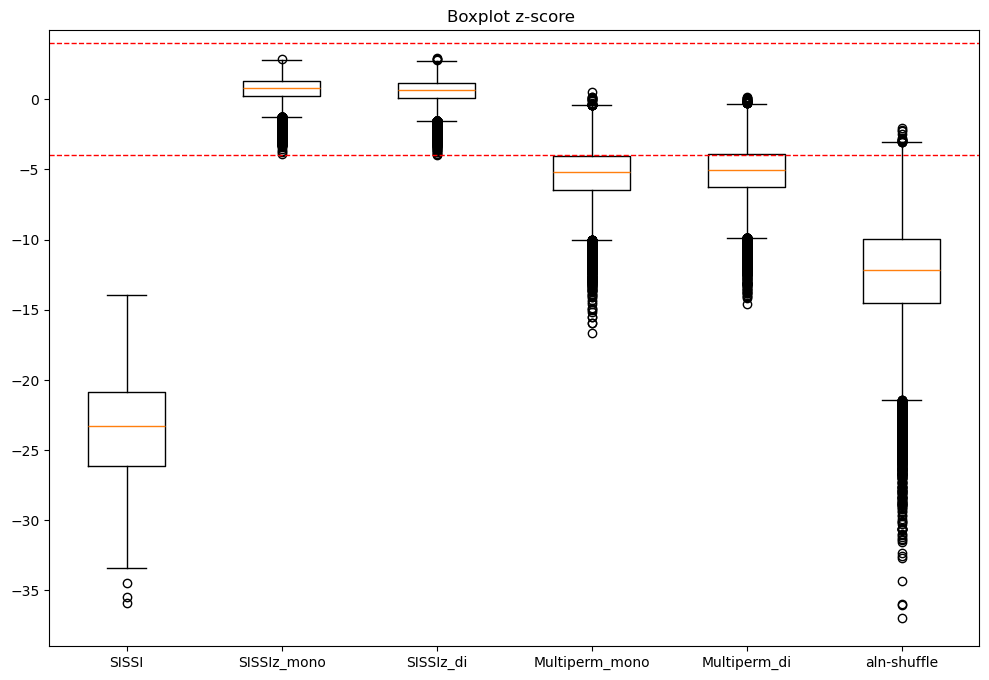

In [25]:
dataframes = [df_sissi, df_sissiz_mono, df_sissiz_di, df_multiperm_mono, df_multiperm_di, df_aln_shuffle]
labels = ['SISSI', 'SISSIz_mono', 'SISSIz_di', 'Multiperm_mono', 'Multiperm_di', 'aln-shuffle']
data = [df['z-score calculated from 7. 8. and 9.'] for df in dataframes]
thresholds = [-4, 4]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot z-score ')
plt.show()